<a href="https://colab.research.google.com/github/piotrekwisniewski/MachineLearning/blob/main/TeamTwo_c3_1_Mieszkalnik_forecast_Rome_linearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mieszkalnik** AirBnB analysis
Part 1: Rome (Italy)

Packages loading

In [1]:
! pip install shap -qq

In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import lasso_path
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import sklearn
import xgboost
import shap
import json

In [3]:
import warnings
# warnings.simplefilter("ignore", category=FutureWarning)
warnings.filterwarnings('ignore')

In [4]:
# import matplotlib
# matplotlib.style.available

In [5]:
# display settings
pd.options.display.max_columns = None
pd.options.display.max_rows = 40

pd.options.mode.copy_on_write = True

# matplotlib plot style
plt.style.use('seaborn-v0_8-dark-palette')

## 1. Data exploratory




#### 1.1. Dataset loading

In [6]:
# Dataset load
data_raw = pd.read_csv("https://data.insideairbnb.com/italy/lazio/rome/2024-09-11/data/listings.csv.gz")  # Rome, Italy

In [7]:
data_raw.info()
# data_raw

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34061 entries, 0 to 34060
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            34061 non-null  int64  
 1   listing_url                                   34061 non-null  object 
 2   scrape_id                                     34061 non-null  int64  
 3   last_scraped                                  34061 non-null  object 
 4   source                                        34061 non-null  object 
 5   name                                          34061 non-null  object 
 6   description                                   32879 non-null  object 
 7   neighborhood_overview                         19104 non-null  object 
 8   picture_url                                   34061 non-null  object 
 9   host_id                                       34061 non-null 

In [8]:
# Creating target dataframe
df = data_raw.copy()

### 1.2. Data cleansing

In [9]:
# diplaying empty values
data_raw_na = data_raw.isna().sum()
data_raw_na[data_raw_na > 0].sort_values(ascending=False)

,0
neighbourhood_group_cleansed,34061
calendar_updated,34061
license,22866
host_neighbourhood,20438
host_about,17735
neighbourhood,14957
neighborhood_overview,14957
host_location,7857
host_response_time,5459
host_response_rate,5459


In [10]:
# dropping columns where more than 80% of values are empty
df = df.dropna(axis=1, thresh= 0.8*data_raw.shape[0])
df.shape

(34061, 67)

In [11]:
df.columns


Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'picture_url', 'host_id', 'host_url', 'host_name',
       'host_since', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url',
       'host_picture_url', 'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms',
       'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'calendar_last_scraped', 'number_of_revi

In [12]:
df = df.loc[:,['id',
        'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'host_verifications',
       'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'availability_30', 'availability_60',
       'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable',
       'reviews_per_month']]

In [13]:
## dataset overview
df.info()
# df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34061 entries, 0 to 34060
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           34061 non-null  int64  
 1   host_response_time           28602 non-null  object 
 2   host_response_rate           28602 non-null  object 
 3   host_acceptance_rate         30612 non-null  object 
 4   host_is_superhost            32654 non-null  object 
 5   host_total_listings_count    34061 non-null  int64  
 6   host_verifications           34061 non-null  object 
 7   host_identity_verified       34061 non-null  object 
 8   neighbourhood_cleansed       34061 non-null  object 
 9   latitude                     34061 non-null  float64
 10  longitude                    34061 non-null  float64
 11  property_type                34061 non-null  object 
 12  room_type                    34061 non-null  object 
 13  accommodates    

### 1.3. EDA (exploratory data analysis) with SwitViz

In [14]:
# !pip install sweetviz -qq

In [15]:
# import sweetviz as sv

# report = sv.analyze(df, pairwise_analysis='off')
# report.show_html(filepath='Analyze_report.html', layout='vertical', scale=None)
# # report.show_notebook()

### 1.4. Price (target variable processing)

In [16]:
# exchanging prices from str to float
df['price'] = df['price'].str.replace('[$,]', '', regex=True).astype('float')

## otherway 1:
# df['price'] = df['price'].str.replace("$","").str.replace(",","").astype("float")

## otherway 2:
# df.price = df.price.apply(lambda x: x.replace("$", ""))
# df.price = df.price.apply(lambda x: x.replace(",", ""))
# df.price = df.price.astype('float')

In [17]:
# filling Nan prices with median
df['price'] = df['price'].fillna(df['price'].median())

In [18]:
df.price.describe()

,price
count,34061.000000
mean,205.341681
std,616.687411
min,8.000000
25%,104.000000
50%,142.000000
75%,199.000000
max,72000.000000


In [19]:
# check outliers
outl_percent = 92
outl_thresh = np.percentile(df.price, outl_percent)
print(f"{outl_percent}% properties have a price lower than {outl_thresh: .2f}")


92% properties have a price lower than  345.00


In [20]:
# getting rid of outliers
df = df[(df.price <= outl_thresh) & (df.price > 10)]

<Axes: >

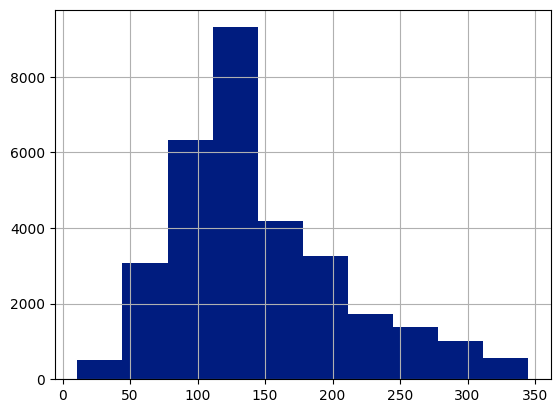

In [21]:
df.price.hist()

#### 1.4.1. Price range

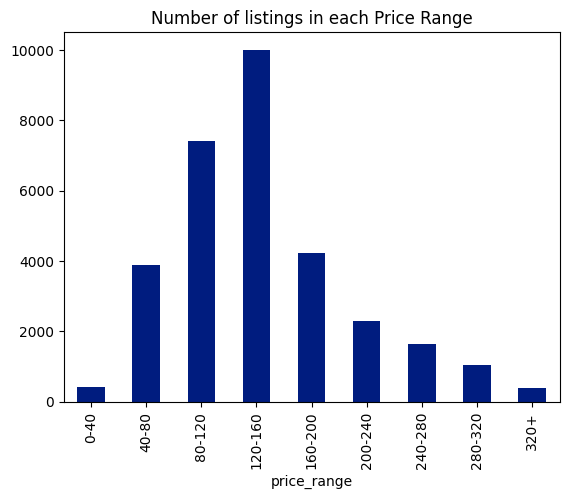

In [22]:
# create column price_range

price_range = pd.cut(df['price'],
                     bins=[0, 40, 80, 120, 160, 200, 240, 280, 320, df['price'].max()],
                     labels=['0-40', '40-80', '80-120', '120-160', '160-200', '200-240', '240-280', '280-320', '320+'])

df['price_range'] = price_range
df['price_range'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of listings in each Price Range")
plt.show()


### 1.5. Data type exchange and missing data treatment

In [23]:
# type exchange and boolean decoding

# encoding boolean
tfs = ['host_is_superhost', 'host_identity_verified', 'instant_bookable']
for col in tfs:
    df[col] = df[col].fillna('f')
    df[col] = df[col].apply(lambda x: 1 if x == 't' else 0)

# decoding percentage
for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col] = df[col].str[:-1].astype('float')/100

In [24]:
# missing data treatment

df['bedrooms'] = df['bedrooms'].fillna(1)
df['bathrooms'] = df['bathrooms'].fillna(1)
df['beds'] = df['beds'].fillna(df['accommodates'])

# # reviews
# for col in ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
#             'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
#             'review_scores_value', 'reviews_per_month']:
#     df[col] = df[col].fillna(df[col].mean())

# any other missing values completing using SimpleImputer
from sklearn.impute import SimpleImputer

numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

numeric_imputer = SimpleImputer(strategy='mean')
categorical_imputer = SimpleImputer(strategy='most_frequent')

# Apply imputer to numeric columns in dataframe
df[numeric_cols] = numeric_imputer.fit_transform(df[numeric_cols])
df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

### Adding features

#### amenities

In [25]:
# list of dictionaries with amenity and it's synonyms
main_amenities = [
    {'wifi': ['wifi', 'wi-fi', 'internet']},
    {'tv': ['tv', 'television']},
    {'streaming': ['netflix', 'amazon prime', 'amazon prime video', 'apple tv', 'disney+', 'hbo', 'hbo_max', 'sky showtime']},
    {'air_conditioning': ['air conditioning', 'air-conditioning', 'ac', 'air-con']},
    {'refrigerator': ['refrigerator', 'fridge']},
    {'kitchen': ['kitchen']},
    {'essentials': ['essentials', 'hair dryer', 'hot water kettle', 'hot water', 'dishes', 'bed linens', 'towels']}
]

for amenity_dict in main_amenities:
    colname = "is_" + list(amenity_dict.keys())[0]  # feature column name
    synonyms = list(amenity_dict.values())[0]       # list of amenity synonyms
    df[colname] = df['amenities'].apply(lambda x: any(synonym in x.lower() for synonym in synonyms)) * 1

# total number of amenities
df['n_amenities'] = df['amenities'].apply(lambda x: len(x.split(",")))


#### location - geoplot

<Axes: xlabel='longitude', ylabel='latitude'>

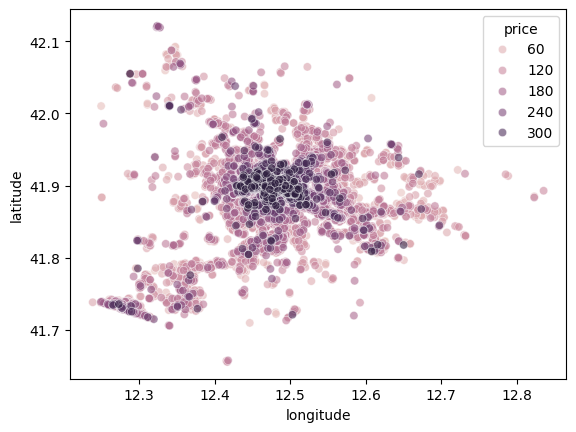

In [26]:
import plotly.graph_objects as go
from plotly.offline import plot as plotoffline
import seaborn as sns
# Create data subset
geo = df[['latitude', 'longitude', 'price', 'price_range']]
geo = geo.sort_values("price", ascending=True) # This sorting is necessary for the color scale to work properly.
geo.describe()
# Simple scatter plot
sns.scatterplot(x="longitude",
                y="latitude",
                hue="price",
                data=geo,
                alpha=0.6)

In [27]:
# get the distance from the mean of all localizations
df['lat_dist_mean']  = df['latitude'].apply(lambda x: (x-np.mean(df['latitude']))**2)
df['lon_dist_mean']  = df['longitude'].apply(lambda x: (x-np.mean(df['longitude']))**2)

#### neighbourhood

In [28]:
# retrieve 20 most popular city areas and assign
top_n = 20
# df['neighbourhood_cleansed'].value_counts().nlargest(top_n).to_dict()
top_nbhds = list(df['neighbourhood_cleansed'].value_counts().nlargest(top_n).index)
df['neighbourhood_cleansed_map'] = df['neighbourhood_cleansed'].apply(lambda x: x if x in top_nbhds else 'other')

#### property type

In [29]:
# retrieve top 6 property types
top_n = 6
# df['property_type'].value_counts().nlargest(top_n).to_dict()
top_pts = list(df['property_type'].value_counts().nlargest(top_n).index)
df['property_type_map'] = df['property_type'].apply(lambda x: x if x in top_pts else 'other')
df['property_type_map']

,property_type_map
0,other
1,Entire rental unit
2,Entire rental unit
3,Entire rental unit
4,Entire rental unit
...,...
34056,Entire rental unit
34057,Entire rental unit
34058,Entire condo
34059,Entire rental unit


In [30]:
# choosing numeric columns and creating a string

all_num_feats = []
feats_to_avoid = ['id', 'url', 'price', 'latitude', 'longitude', 'lat_dist_mean', 'lon_dist_mean' ]
numeric_cols = df.select_dtypes(exclude=['object']).columns

for col in numeric_cols:
    if not any(feat in col for feat in feats_to_avoid):
        all_num_feats.append(col)

## alternatively the same in one row:
# all_num_feats = [col for col in df2.dtypes[df2.dtypes != 'object'].index if not any (feat in col for feat in feats_to_avoid)]

# string for statsmodel

str_for_model = "price ~ " + " \n + ".join(all_num_feats) + "\n + C(neighbourhood_cleansed_map) \n + C(property_type_map)"
# str_for_model = "price ~ " + " \n + ".join(all_num_feats) + "\n+ C(neighbourhood_cleansed_map,  Treatment(reference='other')) \n+ C(property_type_map,  Treatment(reference='other'))"
print(str_for_model)

price ~ host_response_rate 
 + host_acceptance_rate 
 + host_is_superhost 
 + host_total_listings_count 
 + accommodates 
 + bathrooms 
 + bedrooms 
 + beds 
 + minimum_nights 
 + maximum_nights 
 + availability_30 
 + availability_60 
 + number_of_reviews 
 + review_scores_rating 
 + review_scores_accuracy 
 + review_scores_cleanliness 
 + review_scores_checkin 
 + review_scores_communication 
 + review_scores_location 
 + review_scores_value 
 + instant_bookable 
 + reviews_per_month 
 + is_wifi 
 + is_tv 
 + is_streaming 
 + is_air_conditioning 
 + is_refrigerator 
 + is_kitchen 
 + is_essentials 
 + n_amenities
 + C(neighbourhood_cleansed_map) 
 + C(property_type_map)


In [31]:
df1 = df[df['review_scores_location']==5].copy()
df1['neighbourhood_cleansed_map'].value_counts()

,count
neighbourhood_cleansed_map,
I Centro Storico,2798
VII San Giovanni/Cinecittà,336
II Parioli/Nomentano,336
XIII Aurelia,261
XII Monte Verde,179
X Ostia/Acilia,168
V Prenestino/Centocelle,160
VIII Appia Antica,146
XIV Monte Mario,95


# Modelling

In [32]:
# dataset dividing for train and test subsets
from sklearn.model_selection import train_test_split

X = df.drop(columns='price')
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
trainset = pd.concat([X_train, y_train], axis=1)

## Model fit

In [34]:
# linear model
model = smf.ols(str_for_model, data=trainset).fit()

# Inspect the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.421
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     363.6
Date:                Mon, 13 Jan 2025   Prob (F-statistic):               0.00
Time:                        13:57:14   Log-Likelihood:            -1.3276e+05
No. Observations:               25072   AIC:                         2.656e+05
Df Residuals:                   25021   BIC:                         2.660e+05
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [35]:
# Calculate residuals
residuals = y_train - model.predict(X_train)
# Calculate RMSE
rmse = np.sqrt(np.mean(residuals**2))

# # otherway:
# rmse = np.sqrt(np.mean(model.resid**2))
rmse

48.24922623576681

In [36]:
px.histogram(model.resid)

# LASSO

In [37]:
df.columns

Index(['id', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'host_verifications',
       'host_identity_verified', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights',
       'maximum_nights', 'availability_30', 'availability_60',
       'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'reviews_per_month',
       'price_range', 'is_wifi', 'is_tv', 'is_streaming',
       'is_air_conditioning', 'is_refrigerator', 'is_kitchen', 'is_essentials',
       'n_amenities', 'lat_dist_mean', 'lon_dist_mean',
       'neighbourhood_cleansed_map', 'property_type_map'],
      dtype='object')

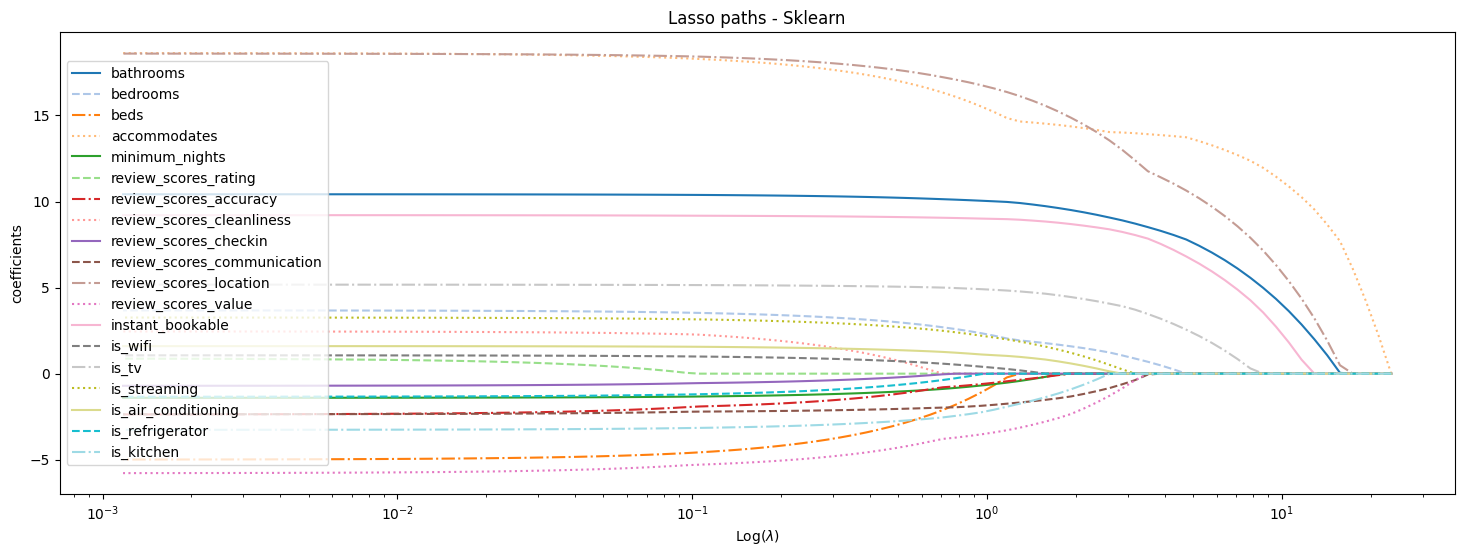

In [38]:
# Lasso

variables = ['bathrooms', 'bedrooms', 'beds', 'accommodates',
             'minimum_nights', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable' ] + ['is_wifi', 'is_tv', 'is_streaming',
            'is_air_conditioning', 'is_refrigerator', 'is_kitchen']

## base for feature choosing:
# variables = ['host_is_superhost', 'bathrooms', 'bedrooms', 'beds', 'accommodates',
#              'minimum_nights', 'number_of_reviews',
#              'review_scores_rating', 'reviews_per_month'] + ['is_wifi', 'is_tv', 'is_streaming',
#             'is_air_conditioning', 'is_refrigerator', 'is_kitchen', 'is_washer',
#             'is_essentials', 'n_amenities']


data_subset = df.loc[:, variables + ['price']]
data_subset.dropna(inplace=True)

X = data_subset.loc[:,variables]
X = preprocessing.scale(X)
y = np.array(data_subset.price)

alphas_lasso, coefs_lasso, _ = lasso_path(X, y, eps = 5e-5)

# colors and plot styles
colors = plt.cm.tab20(np.linspace(0, 1, len(variables)))  # Paleta kolorów
line_styles = ['-', '--', '-.', ':']  # Style linii

# display plot
plt.figure(figsize=(18, 6))
for i in range(X.shape[1]):
    plt.plot(alphas_lasso, coefs_lasso[i], label=variables[i], color=colors[i % len(colors)], linestyle=line_styles[i % len(line_styles)])

plt.xscale('log')
plt.xlabel('Log($\\lambda$)')
plt.ylabel('coefficients')
plt.title('Lasso paths - Sklearn')
plt.legend()
plt.axis('tight')
plt.show()


# xgBoost

In [39]:
# XGBoost


variables = ['bathrooms', 'bedrooms', 'beds', 'accommodates',
             'minimum_nights', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable' ] + ['is_wifi', 'is_tv', 'is_streaming',
            'is_air_conditioning', 'is_refrigerator', 'is_kitchen']



data_subset = df.loc[:, variables + ['price']]
data_subset.dropna(inplace=True)
data_subset = data_subset.iloc[:10000,:]
# data_subset = data_subset.sample(n=20000, random_state=42)
X = data_subset.loc[:, variables]
y = np.array(data_subset['price'])

In [40]:
# dataset split for train and test subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model initialize and fit
xgb_model = xgboost.XGBRegressor(n_estimators=100, verbosity=1, max_depth=5)
xgb_model.fit(X_train, y_train)

# prediction on test dataset
y_test_pred = xgb_model.predict(X_test)

print("R^2 score is: {0: .4f}".format(mean_squared_error(y_test, y_test_pred)))
print("RMSE is: {0: .4f}".format(np.sqrt(mean_squared_error(y_test, y_test_pred))))

# transition to pd.Series
y_test_series = pd.Series(y_test, name='Actual')
y_test_pred_series = pd.Series(y_test_pred, name='Predict')

# Calculate residuals
residuals = y_test_series - y_test_pred_series

R^2 score is:  2242.7875
RMSE is:  47.3581


In [41]:
y_test.mean()

142.9855

In [42]:
results = pd.concat([y_test_series, y_test_pred_series, residuals.rename('Residual')], axis=1)
results

,Actual,Predict,Residual
0,142.0,159.109283,-17.109283
1,142.0,135.796402,6.203598
2,45.0,111.889587,-66.889587
3,96.0,102.695419,-6.695419
4,83.0,86.430473,-3.430473
...,...,...,...
1995,45.0,161.866074,-116.866074
1996,304.0,156.839584,147.160416
1997,219.0,214.503418,4.496582
1998,142.0,134.246872,7.753128


In [43]:
px.histogram(y_test_series - y_test_pred_series)

# XAI - Shapley values

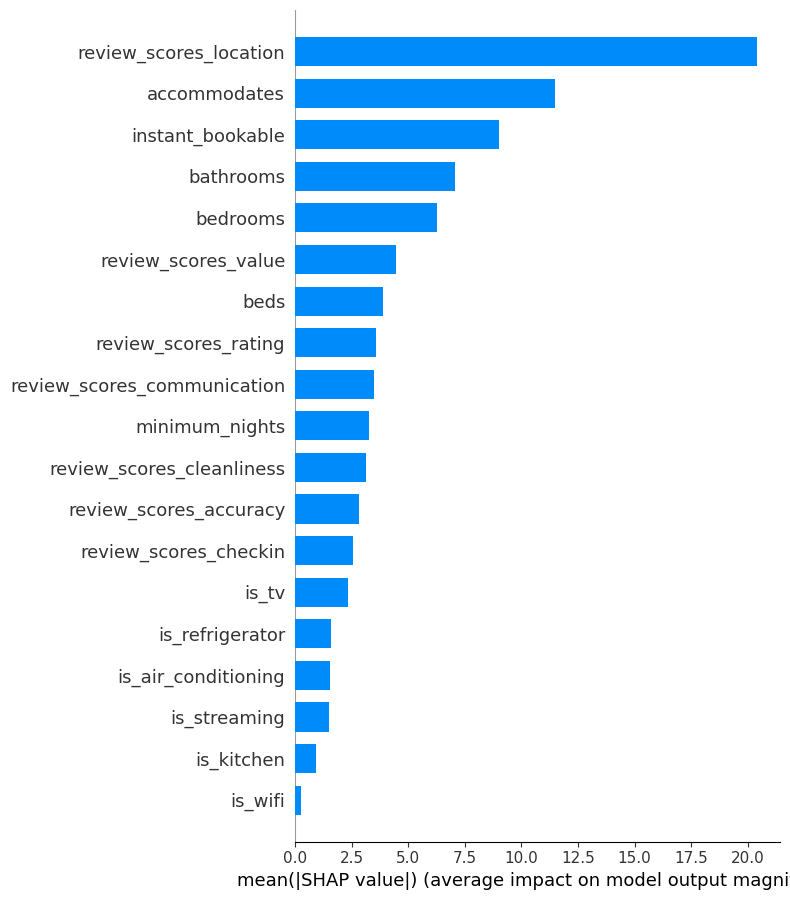

In [44]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

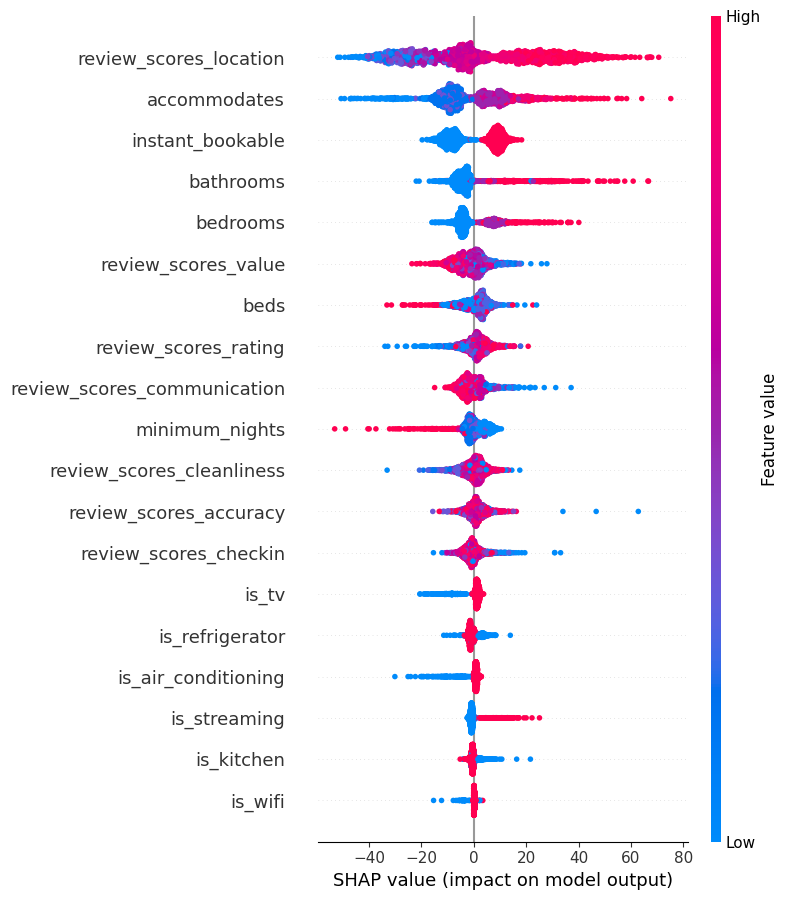

In [45]:
shap.summary_plot(shap_values, features=X_test, feature_names=X_test.columns)

In [46]:
# poniżej wyświetlamy dane i wykresy dla pojedynczego mieszkania:

prop_num = 511  # numer mieszkania z dataframe- poniżej dla niego generują się wykresy
X_test.iloc[prop_num,:]

,3108
bathrooms,1.0
bedrooms,2.0
beds,6.0
accommodates,6.0
minimum_nights,3.0
review_scores_rating,5.0
review_scores_accuracy,5.0
review_scores_cleanliness,5.0
review_scores_checkin,5.0
review_scores_communication,5.0


In [47]:
print(y_test_series[prop_num])
print(y_test_pred_series[prop_num])
print(residuals[prop_num])

142.0
143.5458
-1.545806884765625


<Figure size 1000x800 with 0 Axes>

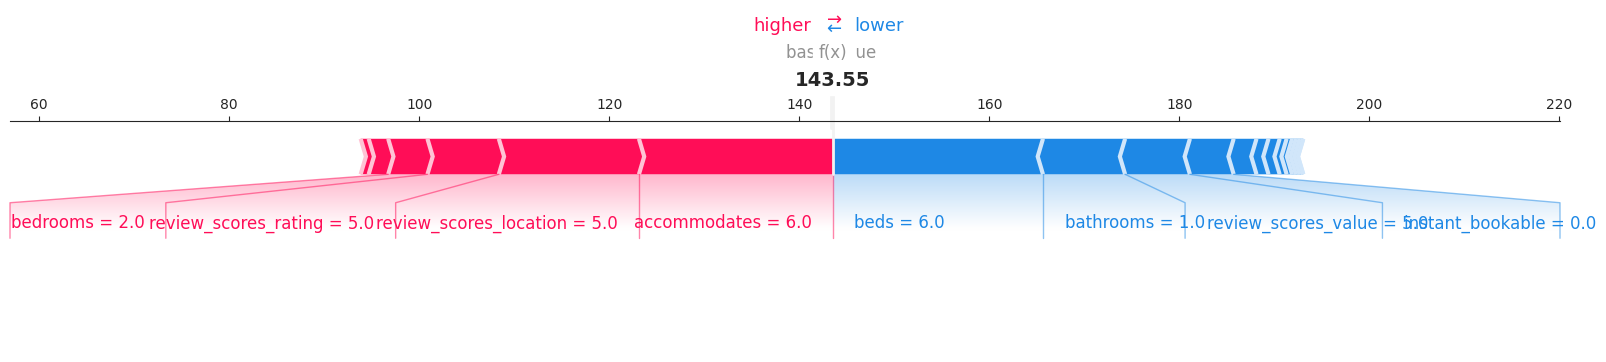

In [48]:
# wykres dla pojedynczego mieszkania
sns.set_style("white")
plt.figure(figsize=(10, 8))
shap.force_plot(explainer.expected_value, shap_values[prop_num,:], X_test.iloc[prop_num,:], matplotlib=True)
plt.show()

In [49]:
# inny wykres
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[prop_num,:], X_test.iloc[prop_num,:], figsize=(10, 6))
